# Genetic Programming

**Context**

This walkthrough will demonstrate genetic programming (GP) in DEAP. To do that we will address the 'odd parity' problem.

Parity is one of the classical GP problems. The input is an array of Boolean values. The solution should output a 'parity bit' of 1 if there are an even number of values, and a 0 otherwise. Usually 6 Boolean inputs are used (Parity-6), and the goal is to match the good parity bit value for each of the possible entries.



In [1]:
import operator
import random
import pygraphviz as pgv
import numpy

from deap import algorithms
from deap import base
from deap import creator
from deap import tools
from deap import gp

# Training data generation

First we initialize the parity problem input and output (target) matrices

In [2]:
PARITY_FANIN_M = 6
PARITY_SIZE_M = 2**PARITY_FANIN_M

inputs = [None] * PARITY_SIZE_M
outputs = [None] * PARITY_SIZE_M

In [3]:
for i in range(PARITY_SIZE_M):
    inputs[i] = [None] * PARITY_FANIN_M
    value = i
    dividor = PARITY_SIZE_M
    parity = 1
    for j in range(PARITY_FANIN_M):
        dividor /= 2
        if value >= dividor:
            inputs[i][j] = 1
            parity = int(not parity)
            value -= dividor
        else:
            inputs[i][j] = 0
    outputs[i] = parity

Let's have a look at the training data that have been generated

In [4]:
len(inputs)

64

In [5]:
for i, o in zip(inputs,outputs):
    print(i,o)

[0, 0, 0, 0, 0, 0] 1
[0, 0, 0, 0, 0, 1] 0
[0, 0, 0, 0, 1, 0] 0
[0, 0, 0, 0, 1, 1] 1
[0, 0, 0, 1, 0, 0] 0
[0, 0, 0, 1, 0, 1] 1
[0, 0, 0, 1, 1, 0] 1
[0, 0, 0, 1, 1, 1] 0
[0, 0, 1, 0, 0, 0] 0
[0, 0, 1, 0, 0, 1] 1
[0, 0, 1, 0, 1, 0] 1
[0, 0, 1, 0, 1, 1] 0
[0, 0, 1, 1, 0, 0] 1
[0, 0, 1, 1, 0, 1] 0
[0, 0, 1, 1, 1, 0] 0
[0, 0, 1, 1, 1, 1] 1
[0, 1, 0, 0, 0, 0] 0
[0, 1, 0, 0, 0, 1] 1
[0, 1, 0, 0, 1, 0] 1
[0, 1, 0, 0, 1, 1] 0
[0, 1, 0, 1, 0, 0] 1
[0, 1, 0, 1, 0, 1] 0
[0, 1, 0, 1, 1, 0] 0
[0, 1, 0, 1, 1, 1] 1
[0, 1, 1, 0, 0, 0] 1
[0, 1, 1, 0, 0, 1] 0
[0, 1, 1, 0, 1, 0] 0
[0, 1, 1, 0, 1, 1] 1
[0, 1, 1, 1, 0, 0] 0
[0, 1, 1, 1, 0, 1] 1
[0, 1, 1, 1, 1, 0] 1
[0, 1, 1, 1, 1, 1] 0
[1, 0, 0, 0, 0, 0] 0
[1, 0, 0, 0, 0, 1] 1
[1, 0, 0, 0, 1, 0] 1
[1, 0, 0, 0, 1, 1] 0
[1, 0, 0, 1, 0, 0] 1
[1, 0, 0, 1, 0, 1] 0
[1, 0, 0, 1, 1, 0] 0
[1, 0, 0, 1, 1, 1] 1
[1, 0, 1, 0, 0, 0] 1
[1, 0, 1, 0, 0, 1] 0
[1, 0, 1, 0, 1, 0] 0
[1, 0, 1, 0, 1, 1] 1
[1, 0, 1, 1, 0, 0] 0
[1, 0, 1, 1, 0, 1] 1
[1, 0, 1, 1, 1, 0] 1
[1, 0, 1, 1, 

# Setting up the algorithm

Our individual will be a function to which we will pass PARITY_FANIN_M values (here 6). As such, you need to define a primitive set that takes in that number of values. You would increase this if you wanted to pass more values, and have it at zero if your individual does not receive any arguments when it is executed.

In [6]:
#pset = gp.PrimitiveSet("MAIN", 0)
pset = gp.PrimitiveSet("MAIN", PARITY_FANIN_M, "IN")

By default input arguments are termed ARG0, ARG2 ... ARGi. We're fine with that here, but let's look at how to name the first argument ARG0 to x.

In [7]:
#pset.renameArguments(ARG0='x')

# Now let's add some functions

We now register our functions and terminals. We would normally not know the function in advance, and might want to start with a limited set and then expand if needed.

In [8]:
pset.addPrimitive(operator.and_, 2)
pset.addPrimitive(operator.or_, 2)
pset.addPrimitive(operator.xor, 2)
pset.addPrimitive(operator.not_, 1)
pset.addTerminal(1)
pset.addTerminal(0)

It's possible to use other functions, such as math ones, but we're limited to logic functions here.

In [9]:
#pset.addPrimitive(operator.add, 2)
#pset.addPrimitive(operator.sub, 2)
#pset.addPrimitive(operator.mul, 2)
#pset.addPrimitive(protectedDiv, 2)
#pset.addPrimitive(operator.neg, 1)
#pset.addPrimitive(math.sin, 1)
#pset.addPrimitive(math.cos, 1)

You can also add an **ephemeral Constant**. The value of the constant is randomly initialised and then kept constant for a particular individual tree, but will differ from one Tree to another. Again, we do not need that here.

In [10]:
#pset.addEphemeralConstant("rand101", lambda: random.randint(-1,1))

Note that we have used lambda to create an anonymous function on the fly. This is so that we can define the arguments to randint to constrain it between -1 and 1.

In [11]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

The only real decision that you need to make when defining populations in the toolbox is what type of initialization you want to use. Individuals will always be of type toolbox.expr.

In [12]:
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=3, max_=5)

In [13]:
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

In [14]:
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

You might consider adding some limits on the height of any generated branch.

In [15]:
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=4))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=5))

## Evaluation function

Provided below is the evaluation function that you should use.

In [16]:
def evalParity(individual):
    func = toolbox.compile(expr=individual)
    return sum(func(*in_) == out for in_, out in zip(inputs, outputs)),

In [17]:
toolbox.register("evaluate", evalParity)

## Register some stats

In [18]:
stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
stats_size = tools.Statistics(len)
mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
mstats.register("avg", numpy.mean)
mstats.register("std", numpy.std)
mstats.register("min", numpy.min)
mstats.register("max", numpy.max)

## Main algorithm

Before, you've always seen the full algorithm coded out. You can do the same here, but for brevity in this walkthrough I have used eaSimple.

In [19]:
pop = toolbox.population(n=500)
hof = tools.HallOfFame(1)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.1, ngen=150, stats=mstats,
                                   halloffame=hof, verbose=True)

   	      	                    fitness                     	                      size                     
   	      	------------------------------------------------	-----------------------------------------------
gen	nevals	avg   	gen	max	min	nevals	std     	avg   	gen	max	min	nevals	std    
0  	500   	31.988	0  	36 	26 	500   	0.596537	18.508	0  	63 	4  	500   	10.5485
1  	283   	32.138	1  	40 	31 	283   	0.714812	17.818	1  	63 	1  	283   	10.7408
2  	270   	32.306	2  	40 	24 	270   	1.21341 	19.198	2  	53 	1  	270   	12.3377
3  	282   	32.868	3  	40 	32 	282   	1.72586 	21.5  	3  	52 	1  	282   	13.9749
4  	300   	34.02 	4  	40 	30 	300   	2.29076 	28.876	4  	51 	1  	300   	14.2004
5  	284   	35.686	5  	40 	28 	284   	2.47293 	36.388	5  	53 	1  	284   	9.33924
6  	285   	37.456	6  	44 	28 	285   	2.60539 	37.72 	6  	53 	1  	285   	5.10976
7  	302   	38.828	7  	44 	28 	302   	2.54449 	36.544	7  	46 	16 	302   	3.14961
8  	265   	39.752	8  	44 	28 	265   	2.27387 	35.526	8  	43 	1  

## Basic plots

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline

gen = log.chapters['fitness'].select("gen")
_min = log.chapters['fitness'].select("min")
_max = log.chapters['fitness'].select("max")
avgs = log.chapters['fitness'].select("avg")
stds = log.chapters['fitness'].select("std")

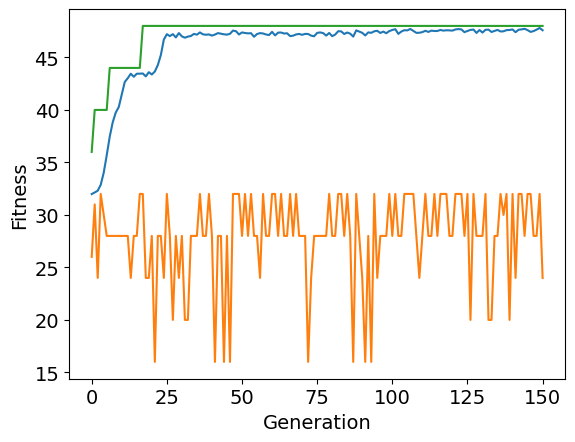

In [21]:
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)

fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, avgs)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness")

line2 = ax1.plot(gen, _min)
line3 = ax1.plot(gen, _max)

Sometimes you might not be able to show the min and max on the same figure because of the scales.

Question: Why do you think the minimum is always so low?

## Let's examine our best individual

In [22]:
indv = tools.selBest(pop, 1)[0]
print(indv)

xor(or_(xor(not_(not_(IN4)), or_(IN4, or_(IN0, IN5))), and_(IN3, or_(or_(1, IN3), IN4))), not_(xor(xor(or_(IN1, IN5), or_(and_(not_(1), not_(IN0)), IN2)), and_(xor(IN0, IN4), or_(IN4, IN3)))))


In [23]:
nodes, edges, labels = gp.graph(indv)

tree = pgv.AGraph()
tree.add_nodes_from(nodes)
tree.add_edges_from(edges)
tree.layout(prog="dot")

for i in nodes:
    n = tree.get_node(i)
    n.attr["label"] = labels[i]

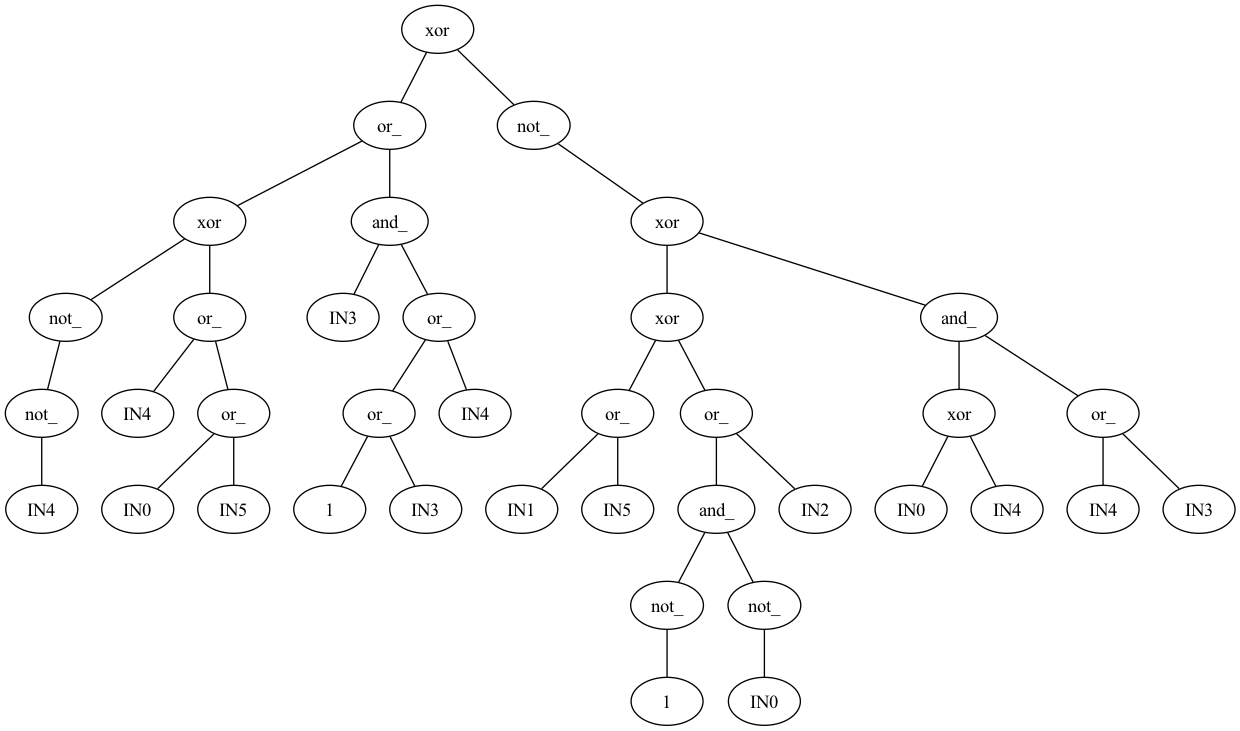

In [24]:
from IPython.display import Image

treePlot = tree.draw(format='png', prog='dot')
Image(treePlot)

In [25]:
toolbox.evaluate(indv)

(48,)

In [26]:
goat = hof[0]
print(goat)

xor(or_(xor(not_(not_(IN4)), or_(IN4, or_(IN0, IN5))), and_(IN3, or_(or_(1, IN3), and_(0, IN3)))), not_(xor(xor(or_(IN1, IN5), or_(0, IN2)), and_(xor(IN0, IN4), or_(IN4, IN3)))))


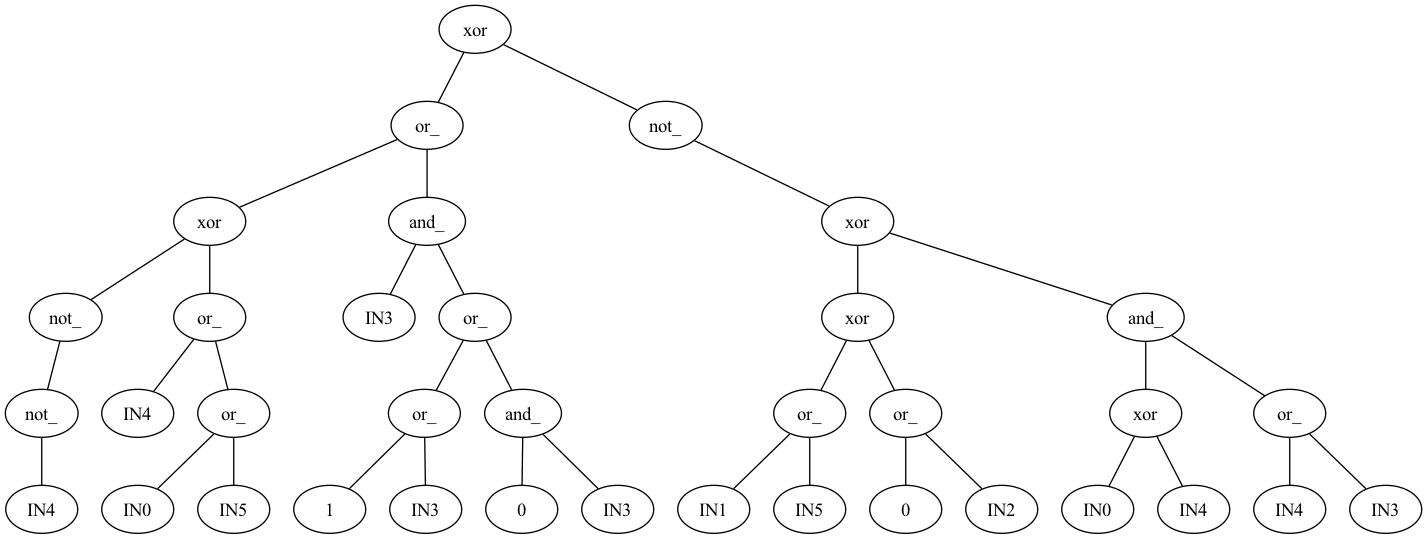

In [27]:
hnodes, hedges, hlabels = gp.graph(goat)

tree = pgv.AGraph()
tree.add_nodes_from(hnodes)
tree.add_edges_from(hedges)
tree.layout(prog="dot")

for i in hnodes:
    n = tree.get_node(i)
    n.attr["label"] = hlabels[i]

from IPython.display import Image

treePlot = tree.draw(format='png', prog='dot')
Image(treePlot)